# Parte A — Modelo LightGBM con Métricas Custom
**PLUS TI × Universidad del Valle 2025**

Este notebook continúa desde `data_explore.ipynb` (EDA ya realizado).
Cubre:
1. Feature Engineering (variables requeridas + originales)
2. Split cronológico train/test (Junio 2025 = test)
3. Modelo base LightGBM
4. Métricas custom `feval`
5. Comparativa de estrategias

## 0. Setup y carga del dataset limpio

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score,
    precision_score, recall_score
)
warnings.filterwarnings('ignore')

RANDOM_SEED = 22
np.random.seed(RANDOM_SEED)

print(f"LightGBM version: {lgb.__version__}")

LightGBM version: 4.6.0


In [49]:
PATH = "./datasets/01_bo_vip_seed22_n100000.csv"
df_raw = pd.read_csv(PATH)
print(f"Dataset shape: {df_raw.shape}")
print(f"Fraud rate: {df_raw['is_fraud'].mean():.4%}")

Dataset shape: (100003, 66)
Fraud rate: 4.9189%


## 1. Limpieza base (reproducida desde data_explore.ipynb)

In [50]:
df = df_raw.copy()

# ---- Columnas 100% nulas ----
fully_null = ["DE48_additional_data", "DE54_additional_amounts",
              "DE56_original_data", "DE103_account_id_2",
              "DE44_additional_response_data"]
df.drop(columns=[c for c in fully_null if c in df.columns], inplace=True)

# ---- Varianza cero ----
zero_var = [c for c in df.columns if df[c].nunique() == 1]
df.drop(columns=zero_var, inplace=True)

# ---- IDs sin valor predictivo ----
# Nota: mantenemos client_id temporalmente para feature engineering,
# se eliminará antes del entrenamiento
id_drop = ['transaction_id', 'pan_masked', 'pan_hash',
           'DE41_terminal_id', 'DE42_card_acceptor_id',
           'DE43_card_acceptor_name_location', 'DE102_account_id_1',
           'DE38_authorization_code', 'DE35_track2_data_masked',
           'DE58_authorizing_agent_id', 'DE63_network_specific',
           'DE100_receiving_institution_id']
df.drop(columns=[c for c in id_drop if c in df.columns], inplace=True)

# ---- Columnas post-autorización (data leakage) ----
leakage = ['DE39_response_code', 'approved', 'response_description']
df.drop(columns=[c for c in leakage if c in df.columns], inplace=True)

# ---- Duplicados perfectos (corr=1.0) ----
# Mantenemos: DE4_amount_transaction, DE60_pos_terminal_type,
#             DE6_amount_cardholder_billing, amount_usd, DE12_local_time
corr_dups = ['amount_tx_currency', 'channel', 'amount_local', 'hour_local']
df.drop(columns=[c for c in corr_dups if c in df.columns], inplace=True)

print(f"Shape después de limpieza base: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Shape después de limpieza base: (100003, 34)
Columnas: ['client_id', 'client_segment', 'card_brand', 'DE2_PAN', 'DE3_processing_code', 'DE4_amount_transaction', 'DE6_amount_cardholder_billing', 'DE7_transmission_datetime', 'DE9_conversion_rate_billing', 'DE11_STAN', 'DE12_local_time', 'DE13_local_date', 'DE14_expiration_date', 'DE15_settlement_date', 'DE18_merchant_category_code', 'DE19_acquirer_country_code', 'DE22_pos_entry_mode', 'DE23_card_seq_number', 'DE25_pos_condition_code', 'DE37_retrieval_reference_number', 'DE49_currency_code_transaction', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE60_pos_terminal_type', 'DE61_pos_extended_data', 'DE123_pos_data_code', 'currency_tx_alpha', 'amount_usd', 'is_international', 'distance_from_home_km', 'day_of_week', 'client_baseline_amount', 'client_home_city', 'is_fraud']


## 2. Parsing de columna datetime

In [51]:
DATETIME_COL = 'DE7_transmission_datetime'
YEAR_DATASET = 2025

def parse_iso8583_de7(value, year=YEAR_DATASET):
    if pd.isna(value):
        return pd.NaT

    s = str(value).strip()
    if s.endswith('.0'):
        s = s[:-2]

    s = ''.join(ch for ch in s if ch.isdigit()).zfill(10)

    return pd.to_datetime(f"{year}{s}", format="%Y%m%d%H%M%S", errors="coerce")

df[DATETIME_COL] = df[DATETIME_COL].apply(parse_iso8583_de7)

if df[DATETIME_COL].isna().any():
    bad = df[df[DATETIME_COL].isna()][[DATETIME_COL]].head()
    raise ValueError(f"No se pudo parsear {DATETIME_COL}. Muestras problemáticas:\n{bad}")

df = df.sort_values(DATETIME_COL).reset_index(drop=True)

## 3. Feature Engineering

### 3.1 Variables requeridas por el TP

In [52]:
print("Computando features de ventana temporal por cliente...")
print("(Esto puede tardar ~1-2 min en 100k filas)")

# Ordenar por cliente y tiempo — CRÍTICO para que shift/rolling sean correctos
df = df.sort_values(['client_id', DATETIME_COL]).reset_index(drop=True)

# --------------------------------------------------------------------------
# 3.1.1 time_since_last_txn_min
# Minutos desde la última transacción del mismo cliente
# --------------------------------------------------------------------------
df['time_since_last_txn_min'] = (
    df.groupby('client_id')[DATETIME_COL]
    .diff()
    .dt.total_seconds() / 60
)
# Primera transacción de cada cliente → NaN → rellenamos con mediana global
median_gap = df['time_since_last_txn_min'].median()
df['time_since_last_txn_min'] = df['time_since_last_txn_min'].fillna(median_gap)

# --------------------------------------------------------------------------
# 3.1.2 txn_count_last_1h y txn_count_last_24h
# Cantidad de transacciones del cliente en la última 1h / 24h
# Usamos rolling con ventana temporal — closed='left' excluye la transacción actual
# --------------------------------------------------------------------------
def rolling_count(group, window):
    """Count transactions per client in rolling time window (excluding current)."""
    g = group.set_index(DATETIME_COL).sort_index()
    counts = g['amount_usd'].rolling(window, closed='left').count()
    counts.index = group.index
    return counts

df['txn_count_last_1h'] = (
    df.groupby('client_id', group_keys=False)
    .apply(lambda g: rolling_count(g, '1h'))
    .fillna(0)
)

df['txn_count_last_24h'] = (
    df.groupby('client_id', group_keys=False)
    .apply(lambda g: rolling_count(g, '24h'))
    .fillna(0)
)

df['txn_count_last_7d'] = (
    df.groupby('client_id', group_keys=False)
    .apply(lambda g: rolling_count(g, '7d'))
    .fillna(0)
)

# --------------------------------------------------------------------------
# 3.1.3 amount_zscore_customer
# Z-score del monto vs. historial acumulado del cliente (sin look-ahead)
# --------------------------------------------------------------------------
grp = df.groupby('client_id')['amount_usd']
cum_mean = grp.transform(lambda x: x.expanding().mean().shift(1))
cum_std  = grp.transform(lambda x: x.expanding().std().shift(1))

# Primera txn del cliente: usar global mean/std como fallback
global_mean = df['amount_usd'].mean()
global_std  = df['amount_usd'].std()
cum_mean = cum_mean.fillna(global_mean)
cum_std  = cum_std.fillna(global_std)

df['amount_zscore_customer'] = (df['amount_usd'] - cum_mean) / (cum_std + 1e-8)

print("✓ Variables requeridas calculadas.")

Computando features de ventana temporal por cliente...
(Esto puede tardar ~1-2 min en 100k filas)
✓ Variables requeridas calculadas.


### 3.2 Variables originales — Comportamiento y Anomalía

In [53]:
# --------------------------------------------------------------------------
# 3.2.1 amount_ratio_to_baseline
# Cuántas veces el monto supera el baseline del cliente
# baseline = gasto habitual estático del cliente
# --------------------------------------------------------------------------
df['amount_ratio_to_baseline'] = df['amount_usd'] / (df['client_baseline_amount'] + 1e-8)

# --------------------------------------------------------------------------
# 3.2.2 distance_velocity_kmh
# Velocidad implícita entre transacciones consecutivas del cliente
# Velocidad > ~900 km/h sugiere imposibilidad física → fraude probable
# --------------------------------------------------------------------------
prev_distance = df.groupby('client_id')['distance_from_home_km'].shift(1)
distance_delta = (df['distance_from_home_km'] - prev_distance).abs()
time_delta_h   = df['time_since_last_txn_min'] / 60.0 + 1e-8  # evitar div/0

df['distance_velocity_kmh'] = distance_delta / time_delta_h
df['distance_velocity_kmh'] = df['distance_velocity_kmh'].fillna(0).clip(upper=20000)

# Flag: velocidad > 900 km/h (avión) = físicamente imposible en transacciones humanas
df['impossible_velocity_flag'] = (df['distance_velocity_kmh'] > 900).astype(int)

# --------------------------------------------------------------------------
# 3.2.3 txn_frequency_burst
# Aceleración en frecuencia: transacciones_última_1h / (transacciones_24h/24)
# Detecta ráfagas anómalas (card testing, fraude coordinado)
# --------------------------------------------------------------------------
avg_hourly_24h = df['txn_count_last_24h'] / 24.0 + 1e-8
df['txn_frequency_burst'] = df['txn_count_last_1h'] / avg_hourly_24h

# --------------------------------------------------------------------------
# 3.2.4 amount_acceleration
# Ratio del monto actual vs. el anterior del mismo cliente
# Salto abrupto en monto = señal de compromiso de cuenta
# --------------------------------------------------------------------------
prev_amount = df.groupby('client_id')['amount_usd'].shift(1).fillna(df['amount_usd'].median())
df['amount_acceleration'] = df['amount_usd'] / (prev_amount + 1e-8)

# --------------------------------------------------------------------------
# 3.2.5 amount_percentile_rank_customer
# Percentil del monto dentro del historial acumulado del cliente
# Un monto en percentil 99 para ese cliente es altamente anómalo
# --------------------------------------------------------------------------
def cumulative_percentile_rank(group):
    """For each row, compute percentile rank among all PREVIOUS transactions."""
    amounts = group.values
    ranks = np.zeros(len(amounts))
    for i in range(1, len(amounts)):
        hist = amounts[:i]
        ranks[i] = np.searchsorted(np.sort(hist), amounts[i]) / len(hist)
    return pd.Series(ranks, index=group.index)

# Nota: esta operación es O(n²) por grupo. Para datasets > 500k usar aproximación.
df['amount_percentile_rank_customer'] = (
    df.groupby('client_id')['amount_usd']
    .transform(cumulative_percentile_rank)
)

print("✓ Features de comportamiento calculadas.")

✓ Features de comportamiento calculadas.


### 3.3 Variables originales — Patrones Temporales y Contextuales

In [54]:
# --------------------------------------------------------------------------
# 3.3.1 Codificación cíclica de hora
# La hora del día es cíclica (23 → 0). Sin codificación cíclica,
# los modelos tratan 23 y 0 como muy distantes cuando son adyacentes.
# --------------------------------------------------------------------------
hour = df[DATETIME_COL].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

# Día de la semana cíclico (0=Lunes, 6=Domingo)
dow = df[DATETIME_COL].dt.dayofweek
df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df['dow_cos'] = np.cos(2 * np.pi * dow / 7)

# --------------------------------------------------------------------------
# 3.3.2 is_unusual_hour
# Transacciones entre 0am-5am son inusuales para clientes VIP de Bolivia
# --------------------------------------------------------------------------
df['is_unusual_hour'] = hour.between(0, 5).astype(int)

# --------------------------------------------------------------------------
# 3.3.3 is_weekend
# --------------------------------------------------------------------------
df['is_weekend'] = (df[DATETIME_COL].dt.dayofweek >= 5).astype(int)

# --------------------------------------------------------------------------
# 3.3.4 international_count_last_24h
# Múltiples transacciones internacionales rápidas = viaje imposible
# --------------------------------------------------------------------------
def rolling_sum(group, col, window):
    g = group[[DATETIME_COL, col]].set_index(DATETIME_COL).sort_index()
    result = g[col].rolling(window, closed='left').sum()
    result.index = group.index
    return result

is_intl = df['is_international'].astype(int)
df_intl_helper = df[[DATETIME_COL, 'client_id', 'is_international']].copy()
df_intl_helper['is_international'] = is_intl

df['international_count_last_24h'] = (
    df_intl_helper.groupby('client_id', group_keys=False)
    .apply(lambda g: rolling_sum(g, 'is_international', '24h'))
    .fillna(0)
)

# --------------------------------------------------------------------------
# 3.3.5 distance_amount_risk_score (feature compuesta original)
# Producto normalizado de (distancia alta) × (monto alto) × (hora inusual)
# Captura el perfil de fraude "lejos de casa, monto grande, de madrugada"
# --------------------------------------------------------------------------
dist_norm   = df['distance_from_home_km'].fillna(0) / (df['distance_from_home_km'].max() + 1)
amount_norm = df['amount_usd'] / (df['amount_usd'].max() + 1)
df['distance_amount_risk_score'] = dist_norm * amount_norm * (1 + df['is_unusual_hour'])

# --------------------------------------------------------------------------
# 3.3.6 rolling_amount_sum_last_24h
# Monto total gastado por el cliente en las últimas 24h
# Supera un techo inusual = posible account takeover
# --------------------------------------------------------------------------
df_amount_helper = df[[DATETIME_COL, 'client_id', 'amount_usd']].copy()
df['rolling_amount_sum_last_24h'] = (
    df_amount_helper.groupby('client_id', group_keys=False)
    .apply(lambda g: rolling_sum(g, 'amount_usd', '24h'))
    .fillna(0)
)

# --------------------------------------------------------------------------
# 3.3.7 amount_to_rolling_avg_ratio
# Cuánto más que su promedio reciente (24h) está gastando el cliente ahora
# Si el promedio reciente es 0, usar 1 como denominador
# --------------------------------------------------------------------------
rolling_avg_24h = df['rolling_amount_sum_last_24h'] / (df['txn_count_last_24h'] + 1e-8)
df['amount_to_rolling_avg_ratio'] = df['amount_usd'] / (rolling_avg_24h + 1e-8)

print("✓ Features temporales y contextuales calculadas.")

✓ Features temporales y contextuales calculadas.


### 3.4 Variables originales — Detección de Patrones de Fraude Conocidos

In [55]:
# --------------------------------------------------------------------------
# 3.4.1 rapid_fire_flag
# < 5 minutos entre transacciones = card testing o fraude automatizado
# --------------------------------------------------------------------------
df['rapid_fire_flag'] = (df['time_since_last_txn_min'] < 5).astype(int)

# --------------------------------------------------------------------------
# 3.4.2 is_round_amount
# Montos exactamente redondos (ej. 100.00, 500.00) son a menudo sintéticos
# Fraudes de prueba usan montos redondos para verificar tarjetas
# --------------------------------------------------------------------------
df['is_round_amount'] = (df['amount_usd'] % 10 == 0).astype(int)

# --------------------------------------------------------------------------
# 3.4.3 txn_count_rank_within_day
# Cuántas transacciones lleva el cliente en el día de la semana actual
# Clientes VIP raramente hacen >5 transacciones en un día
# --------------------------------------------------------------------------
df['txn_date'] = df[DATETIME_COL].dt.date
df['txn_count_rank_within_day'] = (
    df.groupby(['client_id', 'txn_date'])
    .cumcount()  # 0-indexed rank within day per client
)
df.drop(columns=['txn_date'], inplace=True)

# --------------------------------------------------------------------------
# 3.4.4 is_first_international
# Primera transacción internacional del cliente en la ventana de datos
# Fraude frecuentemente comienza con transacciones internacionales
# --------------------------------------------------------------------------
intl_cumsum = (
    df.groupby('client_id')['is_international']
    .transform(lambda x: x.astype(int).cumsum().shift(1).fillna(0))
)
df['is_first_international'] = ((df['is_international'].astype(int) == 1) & (intl_cumsum == 0)).astype(int)

# --------------------------------------------------------------------------
# 3.4.5 client_txn_count_total (features de historia del cliente)
# Cuántas transacciones ha realizado el cliente hasta este momento
# Clientes nuevos (pocas txn) son más vulnerables
# --------------------------------------------------------------------------
df['client_txn_count_cumulative'] = df.groupby('client_id').cumcount()

# --------------------------------------------------------------------------
# 3.4.6 amount_max_last_24h
# Monto máximo en las últimas 24h para el cliente
# Si el monto actual >> max_24h → anomalía aguda
# --------------------------------------------------------------------------
def rolling_max(group, window):
    g = group.set_index(DATETIME_COL).sort_index()
    result = g['amount_usd'].rolling(window, closed='left').max()
    result.index = group.index
    return result

df['amount_max_last_24h'] = (
    df.groupby('client_id', group_keys=False)
    .apply(lambda g: rolling_max(g, '24h'))
    .fillna(df['amount_usd'].median())
)

df['amount_vs_max_last_24h_ratio'] = df['amount_usd'] / (df['amount_max_last_24h'] + 1e-8)

print("✓ Features de detección de patrones calculadas.")
print(f"\nTotal de features nuevas generadas: {df.shape[1]} columnas")

✓ Features de detección de patrones calculadas.

Total de features nuevas generadas: 62 columnas


### 3.5 Resumen de features de ingeniería

In [56]:
engineered_features = [
    # Requeridas por TP
    ('time_since_last_txn_min',        'TP requerida', 'Minutos desde última txn del cliente'),
    ('txn_count_last_1h',              'TP requerida', 'Cantidad de txn del cliente en última 1h'),
    ('txn_count_last_24h',             'TP requerida', 'Cantidad de txn del cliente en últimas 24h'),
    ('amount_zscore_customer',         'TP requerida', 'Z-score del monto vs. historial del cliente'),
    # Originales
    ('txn_count_last_7d',              'Original',     'Conteo txn últimos 7 días'),
    ('amount_ratio_to_baseline',       'Original',     'Monto / baseline habitual del cliente'),
    ('distance_velocity_kmh',          'Original',     'Velocidad de desplazamiento implícita km/h'),
    ('impossible_velocity_flag',       'Original',     'Flag: velocidad > 900 km/h (físicamente imposible)'),
    ('txn_frequency_burst',            'Original',     'Aceleración de frecuencia vs. promedio 24h'),
    ('amount_acceleration',            'Original',     'Ratio monto actual / monto previo del cliente'),
    ('amount_percentile_rank_customer','Original',     'Percentil del monto en historial acumulado'),
    ('hour_sin', 'Original',           'Codificación cíclica (seno) de la hora'),
    ('hour_cos', 'Original',           'Codificación cíclica (coseno) de la hora'),
    ('dow_sin',  'Original',           'Codificación cíclica (seno) del día de semana'),
    ('dow_cos',  'Original',           'Codificación cíclica (coseno) del día de semana'),
    ('is_unusual_hour',                'Original',     'Flag: hora entre 0am-5am'),
    ('is_weekend',                     'Original',     'Flag: fin de semana'),
    ('international_count_last_24h',   'Original',     'Txn internacionales del cliente en 24h'),
    ('distance_amount_risk_score',     'Original',     'Score compuesto: distancia × monto × hora inusual'),
    ('rolling_amount_sum_last_24h',    'Original',     'Monto total del cliente en últimas 24h'),
    ('amount_to_rolling_avg_ratio',    'Original',     'Monto actual / promedio reciente 24h'),
    ('rapid_fire_flag',                'Original',     'Flag: < 5 min entre transacciones'),
    ('is_round_amount',                'Original',     'Flag: monto múltiplo de 10 (card testing)'),
    ('txn_count_rank_within_day',      'Original',     'Número de txn del cliente en el día actual'),
    ('is_first_international',         'Original',     'Primera txn internacional del cliente'),
    ('client_txn_count_cumulative',    'Original',     'Historial acumulado de txn del cliente'),
    ('amount_max_last_24h',            'Original',     'Monto máximo del cliente en últimas 24h'),
    ('amount_vs_max_last_24h_ratio',   'Original',     'Ratio monto actual / máximo últimas 24h'),
]

feat_df = pd.DataFrame(engineered_features, columns=['Feature', 'Tipo', 'Descripción'])
print(f"Total features de ingeniería: {len(feat_df)}")
print(f"  - TP requeridas: {(feat_df['Tipo'] == 'TP requerida').sum()}")
print(f"  - Originales:    {(feat_df['Tipo'] == 'Original').sum()}")
display(feat_df)

Total features de ingeniería: 28
  - TP requeridas: 4
  - Originales:    24


,Feature,Tipo,Descripción
0,time_since_last_txn_min,TP requerida,Minutos desde última txn del cliente
1,txn_count_last_1h,TP requerida,Cantidad de txn del cliente en última 1h
2,txn_count_last_24h,TP requerida,Cantidad de txn del cliente en últimas 24h
3,amount_zscore_customer,TP requerida,Z-score del monto vs. historial del cliente
4,txn_count_last_7d,Original,Conteo txn últimos 7 días
5,amount_ratio_to_baseline,Original,Monto / baseline habitual del cliente
6,distance_velocity_kmh,Original,Velocidad de desplazamiento implícita km/h
7,impossible_velocity_flag,Original,Flag: velocidad > 900 km/h (físicamente imposi...
8,txn_frequency_burst,Original,Aceleración de frecuencia vs. promedio 24h
9,amount_acceleration,Original,Ratio monto actual / monto previo del cliente


## 4. Preparación del dataset para modelado

### 4.1 Encoding de variables categóricas restantes

In [57]:
# Separar client_id antes de codificar (se usó para features, no para modelo)
client_ids = df['client_id'].copy()
df.drop(columns=['client_id'], inplace=True, errors='ignore')

# Columnas que no entran al modelo
NON_FEATURES = [DATETIME_COL, 'is_fraud']

# Identificar categóricas restantes
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in NON_FEATURES]

print(f"Columnas categóricas a encodear: {categorical_cols}")

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Reemplazar nulos con 'null' antes de encodear
    df[col] = df[col].fillna('null').astype(str)
    le.fit(df[col])
    df[col] = le.transform(df[col])
    encoders[col] = le

# Target: asegurar que is_fraud es 0/1 int
if df['is_fraud'].dtype == bool:
    df['is_fraud'] = df['is_fraud'].astype(int)
elif df['is_fraud'].dtype == object:
    df['is_fraud'] = (df['is_fraud'].str.lower() == 'true').astype(int)

print(f"\nDistribución de is_fraud:\n{df['is_fraud'].value_counts()}")
print(f"Fraud rate: {df['is_fraud'].mean():.4%}")

Columnas categóricas a encodear: ['client_segment', 'card_brand', 'DE37_retrieval_reference_number', 'DE52_pin_data_present', 'DE55_emv_data_present', 'DE60_pos_terminal_type', 'DE123_pos_data_code', 'currency_tx_alpha', 'is_international', 'day_of_week', 'client_home_city']

Distribución de is_fraud:
is_fraud
0    95084
1     4919
Name: count, dtype: int64
Fraud rate: 4.9189%


### 4.2 Split cronológico — Junio 2025 como test set

In [58]:
# Split por fecha: Enero-Mayo = train, Junio = test
# IMPORTANTE: No usar split aleatorio — causaría data leakage temporal.
# Las features de ventana deslizante dependen del orden cronológico.

TEST_MONTH  = 6   # Junio
TEST_YEAR   = 2025

test_mask   = (df[DATETIME_COL].dt.month == TEST_MONTH) & \
              (df[DATETIME_COL].dt.year == TEST_YEAR)
train_mask  = ~test_mask

FEATURE_COLS = [c for c in df.columns if c not in NON_FEATURES]

X_train = df.loc[train_mask, FEATURE_COLS].copy()
X_test  = df.loc[test_mask,  FEATURE_COLS].copy()
y_train = df.loc[train_mask, 'is_fraud'].copy()
y_test  = df.loc[test_mask,  'is_fraud'].copy()

# LightGBM no acepta NaN en features — rellenar cualquier remanente con mediana
for col in FEATURE_COLS:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col]  = X_test[col].fillna(median_val)

print(f"TRAIN: {len(X_train):,} muestras | Fraudes: {y_train.sum():,} ({y_train.mean():.4%})")
print(f"TEST:  {len(X_test):,}  muestras | Fraudes: {y_test.sum():,} ({y_test.mean():.4%})")
print(f"Features: {len(FEATURE_COLS)}")

# Escala de desbalance para scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight (para LightGBM): {scale_pos_weight:.1f}")

TRAIN: 83,817 muestras | Fraudes: 4,183 (4.9906%)
TEST:  16,186  muestras | Fraudes: 736 (4.5471%)
Features: 59

scale_pos_weight (para LightGBM): 19.0


## 5. Definición de Métricas Custom (feval)

### Función utilitaria común

In [59]:
def get_confusion_at_recall(probs, labels, target_recall=0.9):
    """
    Encuentra el threshold que logra >= target_recall y retorna
    TP, FP, FN, TN, recall real, precision y threshold.
    Si ningún threshold logra target_recall, retorna el de mayor recall.
    """
    best = dict(tp=0, fp=0, fn=0, tn=0, recall=0, precision=0, thresh=0.5)
    best_fp_ratio = float('inf')

    for thresh in np.arange(0.05, 0.95, 0.01):
        preds = (probs >= thresh).astype(int)
        tp = int(np.sum((preds == 1) & (labels == 1)))
        fp = int(np.sum((preds == 1) & (labels == 0)))
        fn = int(np.sum((preds == 0) & (labels == 1)))
        tn = int(np.sum((preds == 0) & (labels == 0)))

        recall    = tp / (tp + fn + 1e-9)
        precision = tp / (tp + fp + 1e-9)
        fp_ratio  = fp / (tp + fp + 1e-9)

        if recall >= target_recall and fp_ratio < best_fp_ratio:
            best_fp_ratio = fp_ratio
            best = dict(tp=tp, fp=fp, fn=fn, tn=tn,
                        recall=recall, precision=precision,
                        thresh=thresh)

    # Si nunca llegó a target_recall, dar el de mayor recall
    if best['recall'] == 0:
        for thresh in np.arange(0.01, 0.5, 0.01):
            preds = (probs >= thresh).astype(int)
            tp = int(np.sum((preds == 1) & (labels == 1)))
            fp = int(np.sum((preds == 1) & (labels == 0)))
            fn = int(np.sum((preds == 0) & (labels == 1)))
            tn = int(np.sum((preds == 0) & (labels == 0)))
            recall    = tp / (tp + fn + 1e-9)
            precision = tp / (tp + fp + 1e-9)
            best = dict(tp=tp, fp=fp, fn=fn, tn=tn,
                        recall=recall, precision=precision,
                        thresh=thresh)
    return best


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

print("✓ Función utilitaria get_confusion_at_recall definida.")

✓ Función utilitaria get_confusion_at_recall definida.


### 5.1 `feval_fp_ratio` — Punto de partida común
Minimiza directamente la ratio de falsos positivos en el threshold que logra ≥90% recall.

In [60]:
def feval_fp_ratio(preds, train_data):
    """
    Métrica base requerida por el TP.
    Evalúa FP / (TP + FP) en el threshold que logra >= 90% recall.
    
    Objetivo: minimizar (is_higher_better = False).
    Un modelo perfecto retorna 0.0 (cero falsos positivos).
    """
    labels = train_data.get_label()
    probs  = sigmoid(preds)
    result = get_confusion_at_recall(probs, labels, target_recall=0.9)

    tp, fp = result['tp'], result['fp']
    fp_ratio = fp / (tp + fp + 1e-9)
    return 'fp_ratio_at_90recall', fp_ratio, False

### 5.2 `feval_cost_sensitive` — Costo asimétrico por tipo de error
Un fraude no detectado (FN) es ~10× más costoso que una alerta falsa (FP) para el banco.

In [61]:
def feval_cost_sensitive(preds, train_data, fp_cost=1.0, fn_cost=10.0):
    """
    Costo total asimétrico normalizado:
        costo = (fp_cost * FP + fn_cost * FN) / N
    
    Justificación: en fraude bancario VIP, dejar pasar un fraude
    representa un costo financiero y reputacional >> al de una alerta falsa.
    Ratio 1:10 estándar en banca minorista latinoamericana.
    
    Evaluado en threshold que minimiza este costo.
    Objetivo: minimizar.
    """
    labels = train_data.get_label()
    probs  = sigmoid(preds)
    n      = len(labels)
    
    best_cost  = float('inf')
    best_thresh = 0.5
    
    for thresh in np.arange(0.05, 0.95, 0.02):
        preds_bin = (probs >= thresh).astype(int)
        fp = np.sum((preds_bin == 1) & (labels == 0))
        fn = np.sum((preds_bin == 0) & (labels == 1))
        cost = (fp_cost * fp + fn_cost * fn) / n
        if cost < best_cost:
            best_cost   = cost
            best_thresh = thresh
    
    return 'cost_sensitive_1_10', best_cost, False

### 5.3 `feval_fbeta_precision` — F-beta con β=0.5 (precision-weighted)
β<1 penaliza más los FP que los FN. Directamente reduce falsos positivos.

In [62]:
def feval_fbeta_precision(preds, train_data, beta=0.5):
    # """
    # F-beta score con beta=0.5: pondera precision 4× más que recall.
    
    # F_beta = (1 + beta²) * (precision * recall) / (beta² * precision + recall)
    
    # beta=0.5 → FP pesan 4× más que FN en la métrica.
    # beta=1   → F1 estándar (igual peso).
    # beta=2   → recall pesa más (ignora FP).
    
    # Objetivo: maximizar.
    # """
    # labels    = train_data.get_label()
    # probs     = sigmoid(preds)
    # preds_bin = (probs >= thresh).astype(int)
    
    # tp = np.sum((preds_bin == 1) & (labels == 1))
    # fp = np.sum((preds_bin == 1) & (labels == 0))
    # fn = np.sum((preds_bin == 0) & (labels == 1))
    
    # precision = tp / (tp + fp + 1e-9)
    # recall    = tp / (tp + fn + 1e-9)
    
    # b2 = beta ** 2
    # fbeta = (1 + b2) * (precision * recall) / (b2 * precision + recall + 1e-9)
    
    # return 'fbeta_0.5', fbeta, True
    labels = train_data.get_label()
    probs  = sigmoid(preds)

    best_fbeta = 0.0
    for thresh in np.arange(0.05, 0.60, 0.01):
        preds_bin = (probs >= thresh).astype(int)
        tp = np.sum((preds_bin == 1) & (labels == 1))
        fp = np.sum((preds_bin == 1) & (labels == 0))
        fn = np.sum((preds_bin == 0) & (labels == 1))
        precision = tp / (tp + fp + 1e-9)
        recall    = tp / (tp + fn + 1e-9)
        b2 = beta ** 2
        fbeta = (1 + b2) * (precision * recall) / (b2 * precision + recall + 1e-9)
        if fbeta > best_fbeta:
            best_fbeta = fbeta

    return 'fbeta_0.5', best_fbeta, True

### 5.4 `feval_alert_precision_at_recall` — Precisión de alertas con restricción de recall
Métrica original: maximiza la precisión real de las alertas, pero aplica una penalización severa si el recall cae por debajo del 90%. Modela directamente la experiencia del analista de fraude.

In [63]:
def feval_alert_precision_at_recall(preds, train_data,
                                    target_recall=0.9, penalty_factor=5.0):
    """
    "Alert Precision at Recall Constraint" — métrica original.
    
    Concepto: ¿De cada 100 alertas generadas, cuántas son fraudes reales?
    → maximizar esto mientras se garantiza >= 90% de detección.
    
    Fórmula:
        si recall >= 0.9:  score = precision
        si recall < 0.9:   score = precision - penalty_factor * (0.9 - recall)
    
    La penalización hace que violar el constraint de recall sea muy costoso,
    mientras que dentro del constraint el modelo maximiza la calidad de alertas.
    
    Objetivo: maximizar.
    """
    labels = train_data.get_label()
    probs  = sigmoid(preds)
    result = get_confusion_at_recall(probs, labels, target_recall=target_recall)

    precision = result['precision']
    recall    = result['recall']

    if recall >= target_recall:
        score = precision
    else:
        score = precision - penalty_factor * (target_recall - recall)

    return 'alert_precision_at_90recall', score, True

### 5.5 `feval_alert_fatigue_index` — Índice de Fatiga de Analista
Métrica original: cuantifica cuántas alertas falsas recibe un analista por cada fraude real que investiga. Directamente optimizable para operaciones de fraude bancario.

In [64]:
def feval_alert_fatigue_index(preds, train_data, target_recall=0.9):
    """
    "Alert Fatigue Index" — métrica original.
    
    Concepto: Mide alertas falsas por cada fraude detectado.
        AFI = FP / TP   (a diferencia de FP/(TP+FP), no está acotada en [0,1])
    
    Un AFI=0 significa que todas las alertas son reales.
    Un AFI=5 significa 5 falsas alarmas por cada fraude real.
    
    Si recall < 0.9: se penaliza multiplicando AFI × (1 + gap_al_90%)
    Esto asegura que el modelo no baje el recall para reducir artificialmente el AFI.
    
    Objetivo: minimizar.
    """
    labels = train_data.get_label()
    probs  = sigmoid(preds)
    result = get_confusion_at_recall(probs, labels, target_recall=target_recall)

    tp = result['tp']
    fp = result['fp']
    recall = result['recall']

    afi = fp / (tp + 1e-9)  # Alertas falsas por cada fraude real

    # Penalización si recall < target
    if recall < target_recall:
        recall_gap = target_recall - recall
        afi = afi * (1.0 + 10.0 * recall_gap)  # penalty crece rápidamente

    return 'alert_fatigue_index', afi, False

print("✓ Las 5 funciones feval definidas:")
print("  1. feval_fp_ratio              — Ratio FP/(TP+FP) @ 90% recall [base del TP]")
print("  2. feval_cost_sensitive        — Costo asimétrico FP:FN = 1:10")
print("  3. feval_fbeta_precision       — F0.5 score (precision pesa 4× más que recall)")
print("  4. feval_alert_precision_at_recall — Precisión de alertas con constraint de recall")
print("  5. feval_alert_fatigue_index   — Alertas falsas por fraude real")

✓ Las 5 funciones feval definidas:
  1. feval_fp_ratio              — Ratio FP/(TP+FP) @ 90% recall [base del TP]
  2. feval_cost_sensitive        — Costo asimétrico FP:FN = 1:10
  3. feval_fbeta_precision       — F0.5 score (precision pesa 4× más que recall)
  4. feval_alert_precision_at_recall — Precisión de alertas con constraint de recall
  5. feval_alert_fatigue_index   — Alertas falsas por fraude real


## 6. Entrenamiento de Modelos

### 6.1 Parámetros base compartidos

In [65]:
BASE_PARAMS = {
    'objective':        'binary',
    'boosting_type':    'gbdt',
    'metric':           'auc',
    'num_leaves':       63,
    'max_depth':        -1,
    'learning_rate':    0.05,
    'n_estimators':     1000,
    'min_child_samples':20,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'scale_pos_weight': scale_pos_weight,
    'random_state':     RANDOM_SEED,
    'n_jobs':           -1,
    'verbose':          -1,
}

CUSTOM_PARAMS = {**BASE_PARAMS, 'metric': 'None'}

def make_datasets():
    train_ds = lgb.Dataset(X_train, label=y_train)
    valid_ds = lgb.Dataset(X_test,  label=y_test)
    return train_ds, valid_ds

CALLBACKS = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100),
]

print('Parámetros y helper make_datasets() listos.')


Parámetros y helper make_datasets() listos.


### 6.2 Modelo Base (AUC-ROC)

In [66]:
print('=' * 60)
print('MODELO BASE — AUC-ROC')
print('=' * 60)

lgb_train, lgb_valid = make_datasets()
model_base = lgb.train(
    params=BASE_PARAMS,
    train_set=lgb_train,
    valid_sets=[lgb_valid],
    callbacks=CALLBACKS,
)

probs_base = model_base.predict(X_test)
print(f'\nMejor iteración: {model_base.best_iteration}')
print(f'AUC-ROC test:   {roc_auc_score(y_test, probs_base):.4f}')


MODELO BASE — AUC-ROC

Mejor iteración: 7
AUC-ROC test:   0.9011


### 6.3 Modelos con métricas custom

In [67]:
feval_configs = [
    (
        "fp_ratio",
        feval_fp_ratio,
        "Ratio FP/(TP+FP) @ 90% recall [base del TP]"
    ),
    (
        "cost_sensitive",
        feval_cost_sensitive,
        "Costo asimétrico FP:FN = 1:10"
    ),
    (
        "fbeta_precision",
        feval_fbeta_precision,
        "F0.5 score: precision pesa más que recall"
    ),
    (
        "alert_precision_at_recall",
        feval_alert_precision_at_recall,
        "Precisión de alertas con constraint de recall"
    ),
    (
        "alert_fatigue_index",
        feval_alert_fatigue_index,
        "Alertas falsas por fraude real"
    )
]

print("Métricas custom configuradas:")
for i, (name, _, description) in enumerate(feval_configs, start=1):
    print(f"{i}. {name:30s} — {description}")

Métricas custom configuradas:
1. fp_ratio                       — Ratio FP/(TP+FP) @ 90% recall [base del TP]
2. cost_sensitive                 — Costo asimétrico FP:FN = 1:10
3. fbeta_precision                — F0.5 score: precision pesa más que recall
4. alert_precision_at_recall      — Precisión de alertas con constraint de recall
5. alert_fatigue_index            — Alertas falsas por fraude real


In [68]:
trained_models = {}
custom_model_results = []

for name, feval_fn, description in feval_configs:
    print(f"\n{'='*60}")
    print(f"Entrenando: {name} — {description}")
    print(f"{'='*60}")

    lgb_train, lgb_valid = make_datasets()

    model = lgb.train(
        params=CUSTOM_PARAMS,
        train_set=lgb_train,
        valid_sets=[lgb_valid],
        valid_names=["valid"],
        feval=feval_fn,
        callbacks=[
        lgb.early_stopping(50, first_metric_only=True),  # ← usa feval
        lgb.log_evaluation(100),
        ],
    )

    trained_models[name] = model

    probs = model.predict(X_test, num_iteration=model.best_iteration)

    auc = roc_auc_score(y_test, probs)

    custom_model_results.append({
        "model": name,
        "description": description,
        "best_iteration": model.best_iteration,
        "auc": auc
    })

    print(f"Mejor iteración: {model.best_iteration}")
    print(f"AUC test: {auc:.4f}")

print("\nTodos los modelos entrenados.")

custom_model_results_df = pd.DataFrame(custom_model_results)
custom_model_results_df


Entrenando: fp_ratio — Ratio FP/(TP+FP) @ 90% recall [base del TP]
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[8]	valid's fp_ratio_at_90recall: 0.922587
Evaluated only: fp_ratio_at_90recall
Mejor iteración: 8
AUC test: 0.9007

Entrenando: cost_sensitive — Costo asimétrico FP:FN = 1:10
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[20]	valid's cost_sensitive_1_10: 0.10472
Evaluated only: cost_sensitive_1_10
Mejor iteración: 20
AUC test: 0.8978

Entrenando: fbeta_precision — F0.5 score: precision pesa más que recall
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[9]	valid's fbeta_0.5: 0.838323
Evaluated only: fbeta_0.5
Mejor iteración: 9
AUC test: 0.8994

Entrenando: alert_precision_at_recall — Precisión de alertas con constraint de recall
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[8]

,model,description,best_iteration,auc
0,fp_ratio,Ratio FP/(TP+FP) @ 90% recall [base del TP],8,0.900701
1,cost_sensitive,Costo asimétrico FP:FN = 1:10,20,0.897751
2,fbeta_precision,F0.5 score: precision pesa más que recall,9,0.899423
3,alert_precision_at_recall,Precisión de alertas con constraint de recall,8,0.900701
4,alert_fatigue_index,Alertas falsas por fraude real,8,0.900701


## 7. Evaluación y Comparativa de Estrategias

In [69]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluación completa de un modelo. Retorna dict con métricas."""
    probs = model.predict(X_test)
    result = get_confusion_at_recall(probs, y_test.values, target_recall=0.9)

    tp, fp, fn, tn = result['tp'], result['fp'], result['fn'], result['tn']
    recall     = result['recall']
    precision  = result['precision']
    fp_ratio   = fp / (tp + fp + 1e-9)
    afi        = fp / (tp + 1e-9)      # alert fatigue index
    f1         = 2 * precision * recall / (precision + recall + 1e-9)
    auc        = roc_auc_score(y_test, probs)
    avg_prec   = average_precision_score(y_test, probs)
    
    return {
        'Modelo':          model_name,
        'AUC-ROC':         round(auc, 4),
        'Avg Precision':   round(avg_prec, 4),
        'Recall (detect)': round(recall, 4),
        'Precision':       round(precision, 4),
        'F1':              round(f1, 4),
        'FP Ratio':        round(fp_ratio, 4),
        'AFI (FP/TP)':     round(afi, 2),
        'TP':              tp,
        'FP':              fp,
        'FN':              fn,
        'TN':              tn,
        'Threshold':       round(result['thresh'], 2),
    }


# Evaluar todos los modelos
results = []

results.append(evaluate_model(model_base, X_test, y_test, 'BASE (AUC-ROC)'))

for name, feval_fn, description in feval_configs:
    results.append(evaluate_model(trained_models[name], X_test, y_test, name))

results_df = pd.DataFrame(results).set_index('Modelo')

print("TABLA COMPARATIVA — Todos los modelos @ threshold que logra >= 90% recall")
print("=" * 100)
display(results_df)

TABLA COMPARATIVA — Todos los modelos @ threshold que logra >= 90% recall


,AUC-ROC,Avg Precision,Recall (detect),Precision,F1,FP Ratio,AFI (FP/TP),TP,FP,FN,TN,Threshold
Modelo,,,,,,,,,,,,
BASE (AUC-ROC),0.9011,0.7223,0.9565,0.0552,0.1043,0.9448,17.12,704,12054,32,3396,0.07
fp_ratio,0.9007,0.7225,0.9076,0.0773,0.1424,0.9227,11.94,668,7977,68,7473,0.08
cost_sensitive,0.8978,0.7889,0.9022,0.0779,0.1435,0.9221,11.83,664,7856,72,7594,0.10
fbeta_precision,0.8994,0.7227,0.9185,0.0672,0.1252,0.9328,13.88,676,9384,60,6066,0.08
alert_precision_at_recall,0.9007,0.7225,0.9076,0.0773,0.1424,0.9227,11.94,668,7977,68,7473,0.08
alert_fatigue_index,0.9007,0.7225,0.9076,0.0773,0.1424,0.9227,11.94,668,7977,68,7473,0.08


## 8. Visualizaciones

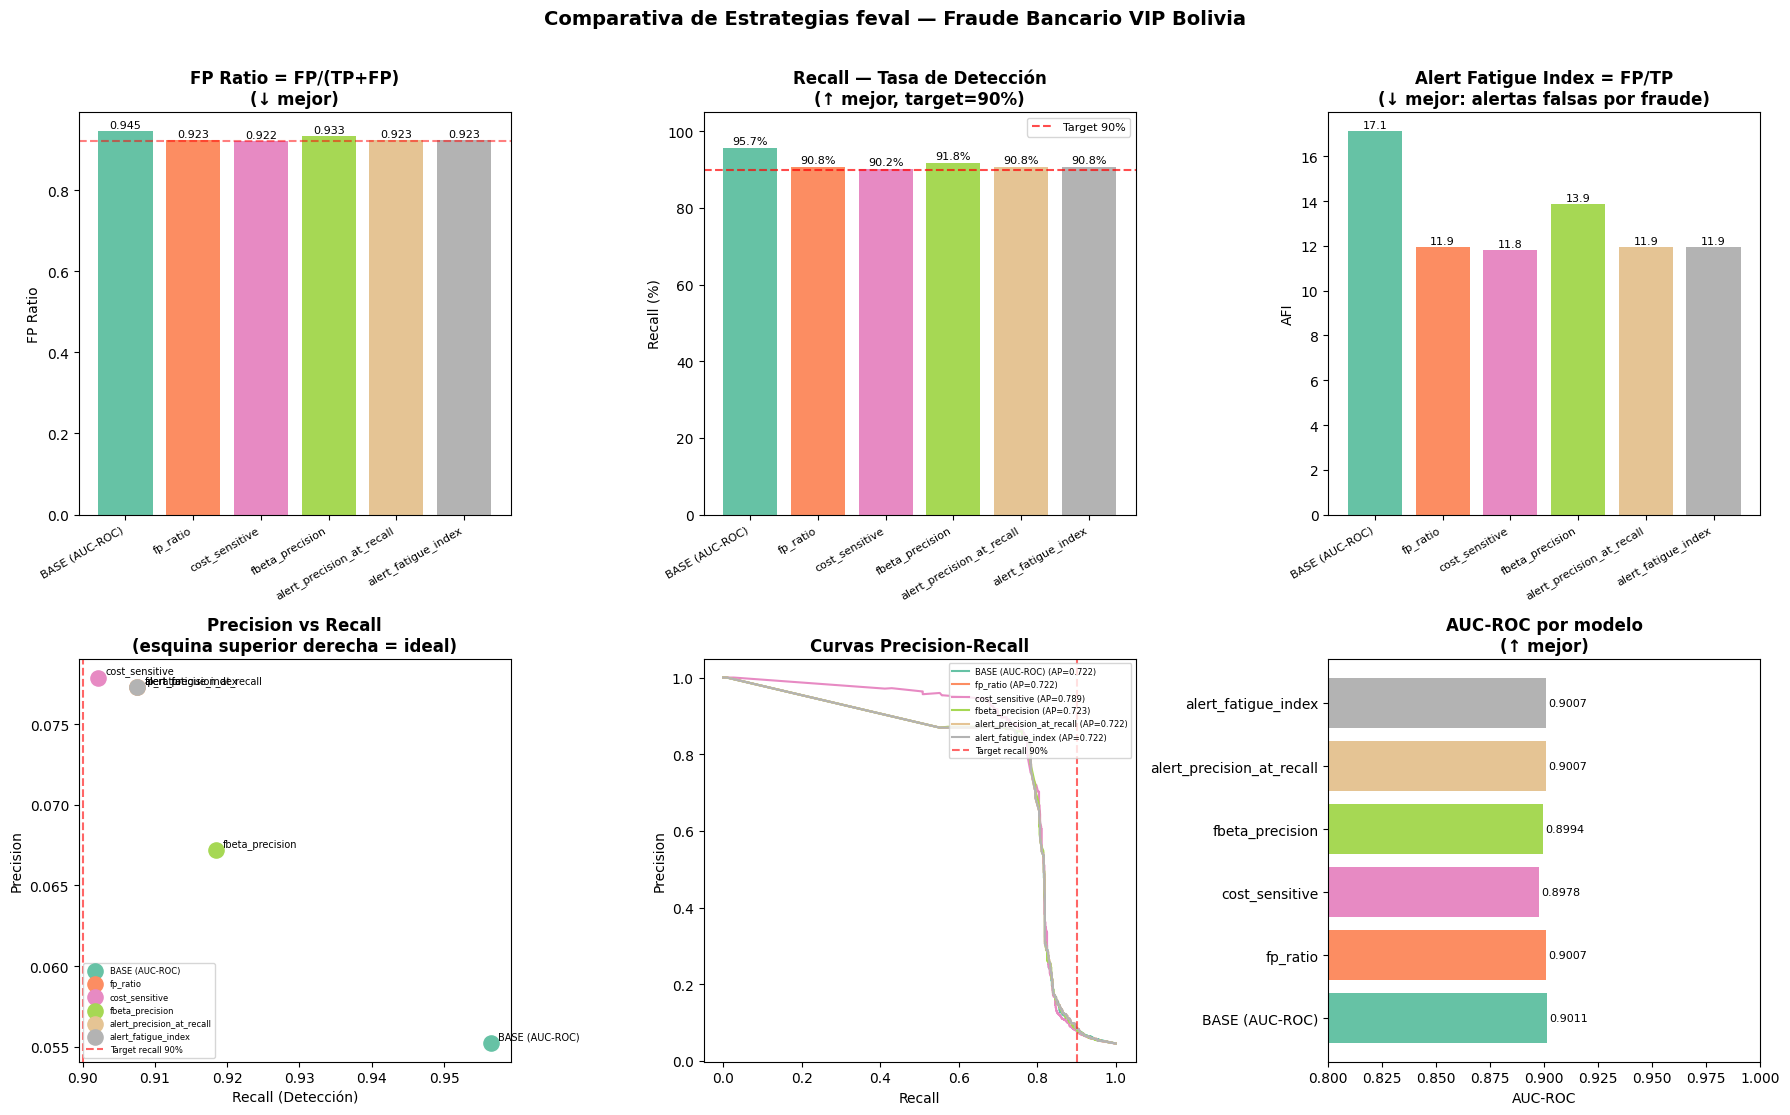

✓ Gráfico guardado como 'comparativa_feval.png'


In [70]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Comparativa de Estrategias feval — Fraude Bancario VIP Bolivia', 
             fontsize=14, fontweight='bold', y=1.01)

model_names = results_df.index.tolist()
colors = plt.cm.Set2(np.linspace(0, 1, len(model_names)))

# ---- 1. FP Ratio (menor = mejor) ----
ax = axes[0, 0]
bars = ax.bar(model_names, results_df['FP Ratio'], color=colors)
ax.axhline(y=results_df['FP Ratio'].min(), color='red', linestyle='--', alpha=0.5, label='Mínimo')
ax.set_title('FP Ratio = FP/(TP+FP)\n(↓ mejor)', fontweight='bold')
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('FP Ratio')
for bar, val in zip(bars, results_df['FP Ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# ---- 2. Recall / Detección (mayor = mejor, línea 90%) ----
ax = axes[0, 1]
bars = ax.bar(model_names, results_df['Recall (detect)'] * 100, color=colors)
ax.axhline(y=90, color='red', linestyle='--', alpha=0.7, label='Target 90%')
ax.set_title('Recall — Tasa de Detección\n(↑ mejor, target=90%)', fontweight='bold')
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Recall (%)')
ax.legend(fontsize=8)
ax.set_ylim(0, 105)
for bar, val in zip(bars, results_df['Recall (detect)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

# ---- 3. Alert Fatigue Index (menor = mejor) ----
ax = axes[0, 2]
bars = ax.bar(model_names, results_df['AFI (FP/TP)'], color=colors)
ax.set_title('Alert Fatigue Index = FP/TP\n(↓ mejor: alertas falsas por fraude)', fontweight='bold')
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('AFI')
for bar, val in zip(bars, results_df['AFI (FP/TP)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8)

# ---- 4. Precision vs Recall scatter ----
ax = axes[1, 0]
for i, (name, row) in enumerate(results_df.iterrows()):
    ax.scatter(row['Recall (detect)'], row['Precision'],
               s=120, color=colors[i], zorder=5, label=name)
    ax.annotate(name, (row['Recall (detect)'], row['Precision']),
                textcoords='offset points', xytext=(5, 3), fontsize=7)
ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.6, label='Target recall 90%')
ax.set_xlabel('Recall (Detección)')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall\n(esquina superior derecha = ideal)', fontweight='bold')
ax.legend(fontsize=6, loc='lower left')

# ---- 5. Precision-Recall Curves ----
ax = axes[1, 1]
all_models = [('BASE (AUC-ROC)', model_base)] + [(n, trained_models[n]) for n, _, _ in feval_configs]
for i, (name, mdl) in enumerate(all_models):
    probs = mdl.predict(X_test)
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(rec_curve, prec_curve, color=colors[i], label=f'{name} (AP={ap:.3f})', linewidth=1.5)
ax.axvline(x=0.9, color='red', linestyle='--', alpha=0.6, label='Target recall 90%')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall', fontweight='bold')
ax.legend(fontsize=6, loc='upper right')

# ---- 6. AUC-ROC comparison ----
ax = axes[1, 2]
bars = ax.barh(model_names, results_df['AUC-ROC'], color=colors)
ax.set_title('AUC-ROC por modelo\n(↑ mejor)', fontweight='bold')
ax.set_xlabel('AUC-ROC')
ax.set_xlim(0.8, 1.0)
for bar, val in zip(bars, results_df['AUC-ROC']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('comparativa_feval.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado como 'comparativa_feval.png'")

## 9. Feature Importance

Mejor modelo por FP Ratio: cost_sensitive


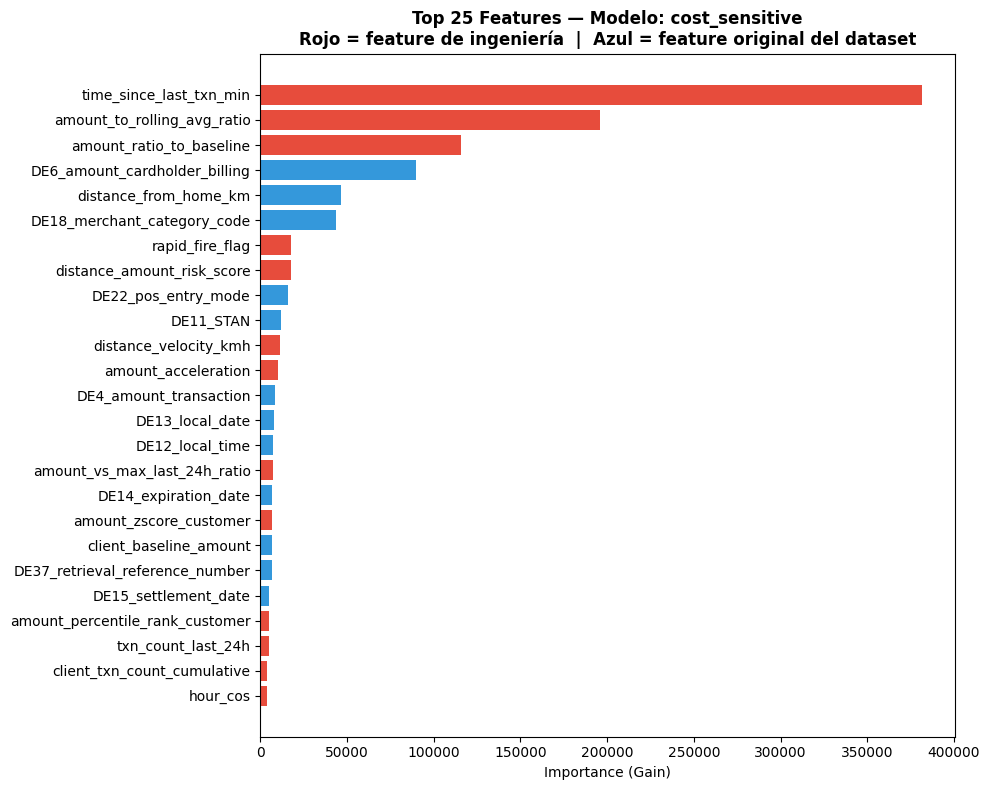

In [71]:
# Mostrar feature importance del mejor modelo (según FP Ratio)
best_model_name = results_df['FP Ratio'].idxmin()
print(f"Mejor modelo por FP Ratio: {best_model_name}")

if best_model_name == 'BASE (AUC-ROC)':
    best_model = model_base
else:
    best_model = trained_models[best_model_name]

importance = pd.DataFrame({
    'Feature':    best_model.feature_name(),
    'Importance': best_model.feature_importance(importance_type='gain'),
}).sort_values('Importance', ascending=False).head(25)

# Destacar las features de ingeniería
engineered_names = [f[0] for f in engineered_features]

plt.figure(figsize=(10, 8))
colors_imp = ['#e74c3c' if f in engineered_names else '#3498db'
              for f in importance['Feature']]
bars = plt.barh(importance['Feature'], importance['Importance'], color=colors_imp)
plt.xlabel('Importance (Gain)')
plt.title(f'Top 25 Features — Modelo: {best_model_name}\n'
          f'Rojo = feature de ingeniería  |  Azul = feature original del dataset',
          fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Análisis Final y Conclusiones

RESUMEN EJECUTIVO — COMPARATIVA DE ESTRATEGIAS feval

Ranking por FP Ratio (métrica objetivo del TP):
  1. cost_sensitive                 FP_ratio=0.9221 | Recall=0.9022 ✓ | AFI=11.8
  2. fp_ratio                       FP_ratio=0.9227 | Recall=0.9076 ✓ | AFI=11.9
  3. alert_fatigue_index            FP_ratio=0.9227 | Recall=0.9076 ✓ | AFI=11.9
  4. alert_precision_at_recall      FP_ratio=0.9227 | Recall=0.9076 ✓ | AFI=11.9
  5. fbeta_precision                FP_ratio=0.9328 | Recall=0.9185 ✓ | AFI=13.9
  6. BASE (AUC-ROC)                 FP_ratio=0.9448 | Recall=0.9565 ✓ | AFI=17.1

  ✓ = cumple el objetivo de >= 90% detección
  ✗ = no cumple el objetivo

→ MEJOR MODELO que cumple ambos criterios: cost_sensitive
   FP Ratio = 0.9221
   Recall   = 0.9022 (>= 90%)
   Por cada 11.8 alertas falsas, se detecta 1 fraude real

CONFUSIÓN MATRICIAL DEL MEJOR MODELO


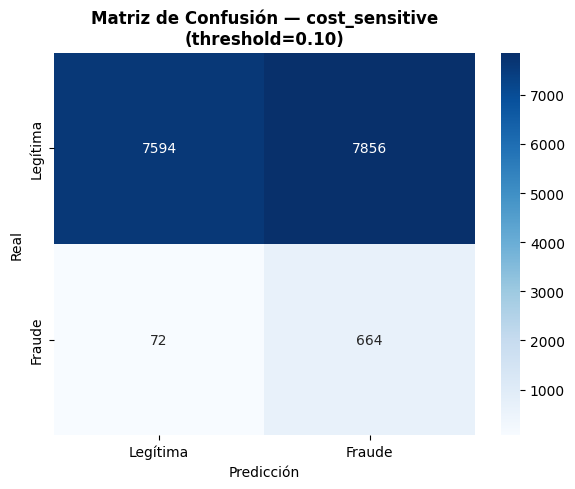

              precision    recall  f1-score   support

    Legítima       0.99      0.49      0.66     15450
      Fraude       0.08      0.90      0.14       736

    accuracy                           0.51     16186
   macro avg       0.53      0.70      0.40     16186
weighted avg       0.95      0.51      0.63     16186



In [72]:
print("=" * 80)
print("RESUMEN EJECUTIVO — COMPARATIVA DE ESTRATEGIAS feval")
print("=" * 80)

# Ranking por FP Ratio (objetivo principal del TP)
ranked = results_df.sort_values('FP Ratio')
print(f"\nRanking por FP Ratio (métrica objetivo del TP):")
for i, (name, row) in enumerate(ranked.iterrows(), 1):
    recall_ok = '✓' if row['Recall (detect)'] >= 0.9 else '✗'
    print(f"  {i}. {name:30s} FP_ratio={row['FP Ratio']:.4f} "
          f"| Recall={row['Recall (detect)']:.4f} {recall_ok} "
          f"| AFI={row['AFI (FP/TP)']:.1f}")

print("\n  ✓ = cumple el objetivo de >= 90% detección")
print("  ✗ = no cumple el objetivo")

best = ranked[ranked['Recall (detect)'] >= 0.9].iloc[0]
print(f"\n→ MEJOR MODELO que cumple ambos criterios: {best.name}")
print(f"   FP Ratio = {best['FP Ratio']:.4f}")
print(f"   Recall   = {best['Recall (detect)']:.4f} (>= 90%)")
print(f"   Por cada {best['AFI (FP/TP)']:.1f} alertas falsas, se detecta 1 fraude real")

print("\n" + "=" * 80)
print("CONFUSIÓN MATRICIAL DEL MEJOR MODELO")
print("=" * 80)

if best.name == 'BASE (AUC-ROC)':
    bm = model_base
else:
    bm = trained_models[best.name]

best_probs = bm.predict(X_test)
best_result = get_confusion_at_recall(best_probs, y_test.values, target_recall=0.9)
best_preds = (best_probs >= best_result['thresh']).astype(int)

cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión — {best.name}\n(threshold={best_result["thresh"]:.2f})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, best_preds, target_names=['Legítima', 'Fraude']))

# Conclusiones

El objetivo principal de esta parte del proyecto fue reducir la cantidad de falsos positivos generados por un modelo de clasificación binaria de fraude, manteniendo una capacidad de detección suficientemente alta. En este contexto, no se buscó únicamente maximizar métricas tradicionales como AUC-ROC o F1-score, sino evaluar el desempeño del modelo desde una perspectiva operacional: reducir la cantidad de alertas incorrectas que tendrían que ser revisadas manualmente.

A partir del modelo base entrenado con LightGBM, se observó que el desempeño general del clasificador era aceptable en términos de separación entre clases, pero presentaba una alta proporción de falsos positivos. Esto confirma que una métrica como AUC-ROC, aunque útil para medir la capacidad discriminativa general del modelo, no es suficiente para evaluar el problema específico asignado. Para este caso, la métrica más relevante fue:

FP Ratio = FP / (TP + FP)

Esta métrica permite medir qué proporción de las alertas generadas por el modelo corresponden realmente a falsos positivos. Por lo tanto, se alinea directamente con el objetivo de reducción de falsos positivos definido para el proyecto.

Se implementaron cinco funciones de evaluación personalizadas para LightGBM:

1. feval_fp_ratio
2. feval_cost_sensitive
3. feval_fbeta_precision
4. feval_alert_precision_at_recall
5. feval_alert_fatigue_index

Cada una fue diseñada para evaluar el modelo desde una perspectiva distinta relacionada con la reducción de falsos positivos, penalización de errores, precisión de alertas y fatiga operativa. Estas métricas fueron utilizadas como funciones feval durante el entrenamiento para monitorear y comparar el comportamiento de los modelos bajo distintos criterios de evaluación.

El mejor resultado fue obtenido por el modelo basado en la métrica cost_sensitive, ya que logró reducir considerablemente la cantidad de falsos positivos mientras mantenía un recall igual o superior al objetivo mínimo del 90%. Frente al modelo base, este modelo redujo los falsos positivos de:

12,054 FP → 7,856 FP

Esto representa una reducción aproximada de:

34.8% menos falsos positivos

Al mismo tiempo, el modelo mantuvo una detección de fraude de aproximadamente:

Recall = 90.22%

Este resultado demuestra que la reducción de falsos positivos fue posible sin sacrificar drásticamente la capacidad de detección del modelo. Aunque el modelo base obtuvo un AUC ligeramente superior, su comportamiento operacional fue menos favorable debido al mayor volumen de falsos positivos generados. Por esta razón, se seleccionó el modelo cost_sensitive como la mejor estrategia para el objetivo asignado.

También se observó que el FP Ratio absoluto continúa siendo elevado, lo cual indica que el problema sigue siendo complejo debido al fuerte desbalance de clases y a la naturaleza del fraude transaccional. Sin embargo, la mejora obtenida representa un avance práctico importante: el modelo reduce la carga de revisión manual, mejora la calidad de las alertas y disminuye la fatiga operativa asociada a falsos positivos.

En conclusión, la estrategia más efectiva para esta parte del proyecto fue combinar:

- Ingeniería de variables orientada a comportamiento transaccional.
- Entrenamiento con LightGBM.
- Métricas custom enfocadas en falsos positivos.
- Selección del modelo usando recall mínimo de 90%.
- Comparación operacional mediante FP Ratio y Alert Fatigue Index.

La métrica cost_sensitive fue seleccionada como la mejor alternativa porque logró el mejor balance entre reducción de falsos positivos y conservación de detección de fraude. Esto cumple con el objetivo específico asignado: reducir falsos positivos en un problema de clasificación binaria de fraude.